# About data Subthemes and polarization - Step 5

In [ ]:
import pandas as pd

# 1. Load your dataset
df = pd.read_csv('PANDEIA_Manual_Labeling_Final.csv')

# 2. Filter for DEIA "yes" posts only
df = df[df['IS_DEIA?'].str.lower() == 'yes'].copy()

# 3. Subtheme Cleaning
themes_validos = ['gender', 'race', 'disability', 'lgbtq+', 'none']

def clean_sub(val):
    if pd.isna(val): return ['none']
    parts = [x.strip().lower() for x in str(val).split(',')]
    cleaned = [p for p in parts if p in themes_validos or 'lgbt' in p]
    return list(set(['lgbtq+' if 'lgbt' in x else x for x in cleaned]))

df['sub_list'] = df['Agreement_Subthemes'].apply(clean_sub)

# --- AUXILIARY FUNCTION TO FORMAT VALUE + % ---
def format_with_pct(df_abs):
    # Calculate percentage per row (axis=1), ignoring the Total column if it already exists
    temp_abs = df_abs.copy()
    row_totals = temp_abs.sum(axis=1)
    df_pct = temp_abs.div(row_totals, axis=0) * 100

    # Create formatted DataFrame "Value (0.0%)"
    df_out = temp_abs.astype(str) + " (" + df_pct.round(1).astype(str) + "%)"

    # Add Total column with absolute value only (without % as it would be 100%)
    df_out['Total'] = row_totals.astype(int).astype(str)
    return df_out

# --- TABLE 1 PROCESSING: SUBTHEMES ---
df_exploded = df.explode('sub_list')
tab1_raw = pd.crosstab(df_exploded['Subreddit'], df_exploded['sub_list'])
# Add General Total row before percentage so it is calculated over the whole
tab1_raw.loc['Overall Total'] = tab1_raw.sum()
tab1_final = format_with_pct(tab1_raw)

# --- TABLE 2 PROCESSING: POLARIZATION ---
df['pol'] = df['Agreement_Polarization'].str.lower().str.strip()
tab2_raw = pd.crosstab(df['Subreddit'], df['pol'])
# Reorder columns
cols_pol = [c for c in ['pro-deia', 'neutral', 'anti-deia'] if c in tab2_raw.columns]
tab2_raw = tab2_raw[cols_pol]
tab2_raw.loc['Overall Total'] = tab2_raw.sum()
tab2_final = format_with_pct(tab2_raw)

# --- LATEX EXPORT ---
# Using booktabs package for professional tables
print("\n% --- TABLE 1: SUBTHEMES (VALUE + %) ---")
print(tab1_final.to_latex(
    column_format='l' + 'c' * len(tab1_final.columns),
    caption='Subtheme Distribution by Subreddit (Manual)',
    label='tab:subthemes_manual',
    bold_rows=True,
    escape=True # Important to handle the % symbol
))

print("\n% --- TABLE 2: POLARIZATION (VALUE + %) ---")
print(tab2_final.to_latex(
    column_format='l' + 'c' * len(tab2_final.columns),
    caption='Polarization Distribution by Subreddit (Manual)',
    label='tab:polarization_manual',
    bold_rows=True,
    escape=True
))


% --- TABLE 1: SUBTHEMES (VALUE + %) ---
\begin{table}
\caption{Subtheme Distribution by Subreddit (Manual)}
\label{tab:subthemes_manual}
\begin{tabular}{lcccccc}
\toprule
sub_list & disability & gender & lgbtq+ & none & race & Total \\
Subreddit &  &  &  &  &  &  \\
\midrule
\textbf{ExperiencedDevs} & 13 (26.5\%) & 16 (32.7\%) & 5 (10.2\%) & 5 (10.2\%) & 10 (20.4\%) & 49 \\
\textbf{cscareerquestions} & 56 (26.0\%) & 64 (29.8\%) & 13 (6.0\%) & 19 (8.8\%) & 63 (29.3\%) & 215 \\
\textbf{girlsgonewired} & 21 (7.8\%) & 172 (63.9\%) & 32 (11.9\%) & 0 (0.0\%) & 44 (16.4\%) & 269 \\
\textbf{womenintech} & 55 (12.2\%) & 289 (64.4\%) & 33 (7.3\%) & 11 (2.4\%) & 61 (13.6\%) & 449 \\
\textbf{Total Geral} & 145 (14.8\%) & 541 (55.1\%) & 83 (8.5\%) & 35 (3.6\%) & 178 (18.1\%) & 982 \\
\bottomrule
\end{tabular}
\end{table}


% --- TABLE 2: POLARIZATION (VALUE + %) ---
\begin{table}
\caption{Polarization Distribution by Subreddit (Manual)}
\label{tab:polarization_manual}
\begin{tabular}{lcccc}
\topr

In [ ]:
import pandas as pd

# 1. Load your dataset (adjust filename if necessary)
df = pd.read_csv('PANDEIA_Manual_Labeling_Final.csv')

# 2. Filter for DEIA "yes" posts only
df = df[df['IS_DEIA?'].str.lower() == 'yes'].copy()

# 3. Subtheme Cleaning (Ensures accurate counting)
themes_validos = ['gender', 'race', 'disability', 'lgbtq+', 'none']

def clean_sub(val):
    if pd.isna(val): return ['none']
    parts = [x.strip().lower() for x in str(val).split(',')]
    cleaned = [p for p in parts if p in themes_validos or 'lgbt' in p]
    return list(set(['lgbtq+' if 'lgbt' in x else x for x in cleaned]))

df['sub_list'] = df['Agreement_Subthemes'].apply(clean_sub)

# --- TABLE 1: SUBTHEMES BY SUBREDDIT ---
# Explode list to count each theme individually
df_exploded = df.explode('sub_list')
tab1 = pd.crosstab(df_exploded['Subreddit'], df_exploded['sub_list'])
tab1['Total'] = tab1.sum(axis=1)
tab1.loc['Overall Total'] = tab1.sum()

# --- TABLE 2: POLARIZATION BY SUBREDDIT ---
# Standardizing the position column
df['pol'] = df['Agreement_Polarization'].str.lower().str.strip()
tab2 = pd.crosstab(df['Subreddit'], df['pol'])
# Reorder columns for academic standard
cols_pol = [c for c in ['pro-deia', 'neutral', 'anti-deia'] if c in tab2.columns]
tab2 = tab2[cols_pol]
tab2['Total'] = tab2.sum(axis=1)
tab2.loc['Overall Total'] = tab2.sum()


df['sub_list'] = df['Agreement_Subthemes'].apply(clean_sub)

df['pol'] = df['Agreement_Polarization'].str.lower().str.strip()

In [ ]:
latex_options = {
    'column_format': 'l' + 'c' * len(tab1.columns), # Left-aligned then centered
    'caption': 'Subthemes per Subreddit (Manual)',
    'label': 'tab:subtemas_subreddit',
    'bold_rows': True,
    'column_to_tex': True
}

# Exporting Table 1 (Subthemes)
print("\n% --- TABLE 1: SUBTHEMES ---")
print(tab1.to_latex())




% --- TABELA 1: SUBTEMAS ---
\begin{tabular}{lrrrrrr}
\toprule
sub_list & disability & gender & lgbtq+ & none & race & Total \\
Subreddit &  &  &  &  &  &  \\
\midrule
ExperiencedDevs & 13 & 16 & 5 & 5 & 10 & 49 \\
cscareerquestions & 56 & 64 & 13 & 19 & 63 & 215 \\
girlsgonewired & 21 & 172 & 32 & 0 & 44 & 269 \\
womenintech & 55 & 289 & 33 & 11 & 61 & 449 \\
Total Geral & 145 & 541 & 83 & 35 & 178 & 982 \\
\bottomrule
\end{tabular}



In [ ]:
# Exporting Table 2 (Polarization)
latex_options['caption'] = 'Polarization per Subreddit (Manual Labeling)'
latex_options['label'] = 'tab:polarization_subreddit'
print("\n% --- TABLE 2: POLARIZATION ---")
print(tab2.to_latex())


% --- TABELA 2: POLARIZAÇÃO ---
\begin{tabular}{lrrrr}
\toprule
pol & pro-deia & neutral & anti-deia & Total \\
Subreddit &  &  &  &  \\
\midrule
ExperiencedDevs & 23 & 5 & 2 & 30 \\
cscareerquestions & 88 & 49 & 29 & 166 \\
girlsgonewired & 167 & 5 & 6 & 178 \\
womenintech & 301 & 20 & 5 & 326 \\
Total Geral & 579 & 79 & 42 & 700 \\
\bottomrule
\end{tabular}



In [ ]:
import pandas as pd

# --- (Previous processing of tab_sub and tab_pol remains the same) ---

# 1. Exporting Subtheme Table
print("\n% --- CONSOLIDATED LLMS TABLE: SUBTHEMES ---")
st_sub = tab_sub.style.format(precision=0) # Ensures integer numbers
print(st_sub.to_latex(
    column_format='ll' + 'c' * len(tab_sub.columns),
    caption="Volumetric Analysis of Subthemes by Prompting Strategy",
    label="tab:llm_subthemes_abs",
    hrules=True,      # This replaces 'booktabs=True' in new versions
    clines="all;index" # Improves visual separation of multi-level index
))

# 2. Exporting Polarization Table
print("\n% --- CONSOLIDATED LLMS TABLE: POLARIZATION ---")
st_pol = tab_pol.style.format(precision=0)
print(st_pol.to_latex(
    column_format='ll' + 'c' * len(tab_pol.columns),
    caption="Volumetric Analysis of Polarization by Prompting Strategy",
    label="tab:llm_polarization_abs",
    hrules=True,
    clines="all;index"
))


% --- TABELA CONSOLIDADA LLMS: SUBTHEMES ---
\begin{table}
\caption{Análise Volumétrica de Subtemas por Estratégia de Prompting}
\label{tab:llm_subthemes_abs}
\begin{tabular}{llccccc}
\toprule
 & Subtema & Disability & Gender & Lgbtq+ & None & Race \\
Modelo & Estratégia &  &  &  &  &  \\
\midrule
\multirow[c]{3}{*}{Deepseek} & Fewshot & 113 & 419 & 40 & 433 & 124 \\
\cline{2-2}
 & Oneshot & 118 & 415 & 43 & 404 & 137 \\
\cline{2-2}
 & Zeroshot & 135 & 441 & 34 & 271 & 157 \\
\cline{1-2} \cline{2-2}
\multirow[c]{3}{*}{Llama} & Fewshot & 120 & 520 & 56 & 341 & 169 \\
\cline{2-2}
 & Oneshot & 146 & 531 & 60 & 300 & 186 \\
\cline{2-2}
 & Zeroshot & 146 & 522 & 59 & 285 & 182 \\
\cline{1-2} \cline{2-2}
\multirow[c]{3}{*}{Mistral} & Fewshot & 99 & 508 & 44 & 365 & 132 \\
\cline{2-2}
 & Oneshot & 114 & 511 & 40 & 348 & 139 \\
\cline{2-2}
 & Zeroshot & 111 & 491 & 43 & 85 & 142 \\
\cline{1-2} \cline{2-2}
\multirow[c]{3}{*}{Phi3} & Fewshot & 72 & 327 & 17 & 530 & 92 \\
\cline{2-2}
 & Oneshot 

In [ ]:
tab_sub_final = tab_sub.copy()
# Adds total row by summing all occurrences for each column
tab_sub_final.loc[('TOTAL', 'Geral'), :] = tab_sub.sum()

# 2. Calculating Totals for Polarization
tab_pol_final = tab_pol.copy()
tab_pol_final.loc[('TOTAL', 'Geral'), :] = tab_pol.sum()

# --- LATEX EXPORT VIA PANDAS ---

# Subthemes
print("\n% --- CONSOLIDATED TABLE: SUBTHEMES WITH TOTAL ---")
print("\\begin{table}[H]")
print("  \\centering")
print("  \\caption{Volumetric Analysis of Subthemes by Prompting Strategy}")
print("  \\label{tab:llm_subthemes_abs}")
print("  \\resizebox{\\textwidth}{!}{% Shrinks the table to fit the page")

# Using .style.to_latex() generates the professional table body
print(tab_sub_final.style.format(precision=0).to_latex(
    column_format='ll' + 'c' * len(tab_sub_final.columns),
    hrules=True,
    clines="all;index"
))

print("  }")
print("\\end{table}")

# Polarization
print("\n% --- CONSOLIDATED TABLE: POLARIZATION WITH TOTAL ---")
print("\\begin{table}[H]")
print("  \\centering")
print("  \\caption{Volumetric Analysis of Polarization by Prompting Strategy}")
print("  \\label{tab:llm_polarization_abs}")
print("  \\resizebox{0.85\\textwidth}{!}{% Shrinks a little less as it has fewer columns")

print(tab_pol_final.style.format(precision=0).to_latex(
    column_format='ll' + 'c' * len(tab_pol_final.columns),
    hrules=True,
    clines="all;index"
))

print("  }")
print("\\end{table}")


% --- TABELA CONSOLIDADA: SUBTHEMES COM TOTAL ---
\begin{table}[H]
  \centering
  \caption{Análise Volumétrica de Subtemas por Estratégia de Prompting}
  \label{tab:llm_subthemes_abs}
  \resizebox{\textwidth}{!}{% Reduz a tabela para caber na página
\begin{tabular}{llccccc}
\toprule
 & Subtema & Disability & Gender & Lgbtq+ & None & Race \\
Modelo & Estratégia &  &  &  &  &  \\
\midrule
\multirow[c]{3}{*}{Deepseek} & Fewshot & 113 & 419 & 40 & 433 & 124 \\
\cline{2-2}
 & Oneshot & 118 & 415 & 43 & 404 & 137 \\
\cline{2-2}
 & Zeroshot & 135 & 441 & 34 & 271 & 157 \\
\cline{1-2} \cline{2-2}
\multirow[c]{3}{*}{Llama} & Fewshot & 120 & 520 & 56 & 341 & 169 \\
\cline{2-2}
 & Oneshot & 146 & 531 & 60 & 300 & 186 \\
\cline{2-2}
 & Zeroshot & 146 & 522 & 59 & 285 & 182 \\
\cline{1-2} \cline{2-2}
\multirow[c]{3}{*}{Mistral} & Fewshot & 99 & 508 & 44 & 365 & 132 \\
\cline{2-2}
 & Oneshot & 114 & 511 & 40 & 348 & 139 \\
\cline{2-2}
 & Zeroshot & 111 & 491 & 43 & 85 & 142 \\
\cline{1-2} \cline{2-

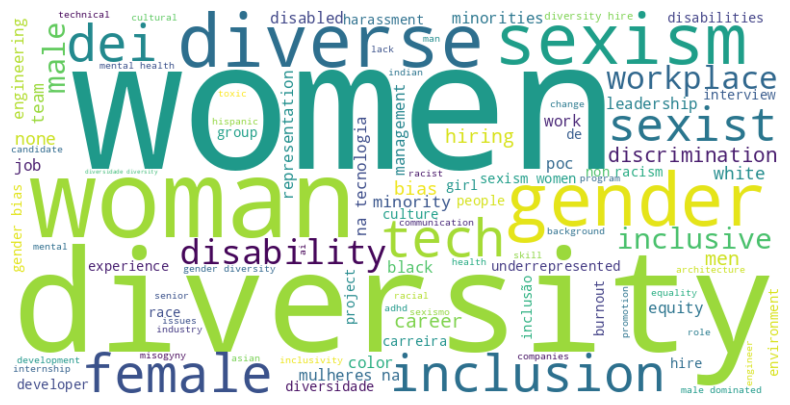

In [ ]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
df_man = pd.read_csv('PANDEIA_Manual_Labeling_Final.csv')
# 1. Function to clean and merge keyword lists
def merge_keywords(row):
    # Converts to string, removes spaces, and splits by comma
    k1 = str(row['KeyWords_x']).lower().split(',') if pd.notna(row['KeyWords_x']) else []
    k2 = str(row['KeyWords_y']).lower().split(',') if pd.notna(row['KeyWords_y']) else []

    # Cleans whitespace from each word and removes empty strings
    list1 = [w.strip() for w in k1 if w.strip()]
    list2 = [w.strip() for w in k2 if w.strip()]

    # Merges lists and removes duplicates using set()
    unique_words = list(set(list1 + list2))

    return ", ".join(unique_words)

# 2. Apply merge to DataFrame
# (Assuming df_man is your manual labeling DataFrame)
df_man['Keywords'] = df_man.apply(merge_keywords, axis=1)

# 3. Prepare text for Word Cloud
# Joins all rows of the new column into a single giant string
text_for_cloud = " ".join(df_man['Keywords'].dropna())

# 4. Generate Word Cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=100,
    contour_width=3,
    contour_color='steelblue'
).generate(text_for_cloud)

# 5. Visualize
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Remove axes (numbers)
plt.savefig('wordcloud_keywords.png', dpi=300, bbox_inches='tight')
plt.show()

# Optional: Save the new CSV with the unified column
#df_man.to_csv('PANDEIA_Manual_Labeling_Final.csv', index=False)

In [ ]:
import pandas as pd

# 1. Data Preparation (Exploding subthemes)
df_exploded = df_man.copy()
df_exploded['sub_list'] = df_exploded['Agreement_Subthemes'].apply(clean_sub)
df_exploded = df_exploded.explode('sub_list')

# 2. Create the Crosstab Table
tab_cross = pd.crosstab(
    df_exploded['sub_list'],
    df_exploded['Agreement_Polarization'].str.lower().str.strip()
)

# Reorder columns for academic standard
cols_pol = [c for c in ['pro-deia', 'neutral', 'anti-deia'] if c in tab_cross.columns]
tab_cross = tab_cross[cols_pol]

# 3. Add Totals (Row and Column)
tab_cross['Total'] = tab_cross.sum(axis=1)
tab_cross.loc['OVERALL TOTAL'] = tab_cross.sum()

# Adjust capitalization for table aesthetics
tab_cross.index = [i.capitalize() for i in tab_cross.index]
tab_cross.columns = [c.capitalize() for c in tab_cross.columns]

# Native Pandas call
print(tab_cross.to_latex(
    column_format='lcccc', # 'l' for index and 'c' for the 4 data columns
    bold_rows=True,
    header=True,
    index=True,
    escape=True
))


\begin{tabular}{lcccc}
\toprule
 & Pro-deia & Neutral & Anti-deia & Total \\
\midrule
\textbf{Disability} & 118 & 35 & 8 & 161 \\
\textbf{Gender} & 489 & 58 & 24 & 571 \\
\textbf{Lgbtq+} & 82 & 8 & 6 & 96 \\
\textbf{None} & 22 & 272 & 7 & 301 \\
\textbf{Race} & 134 & 29 & 21 & 184 \\
\textbf{Total geral} & 845 & 402 & 66 & 1313 \\
\bottomrule
\end{tabular}



# RQ2

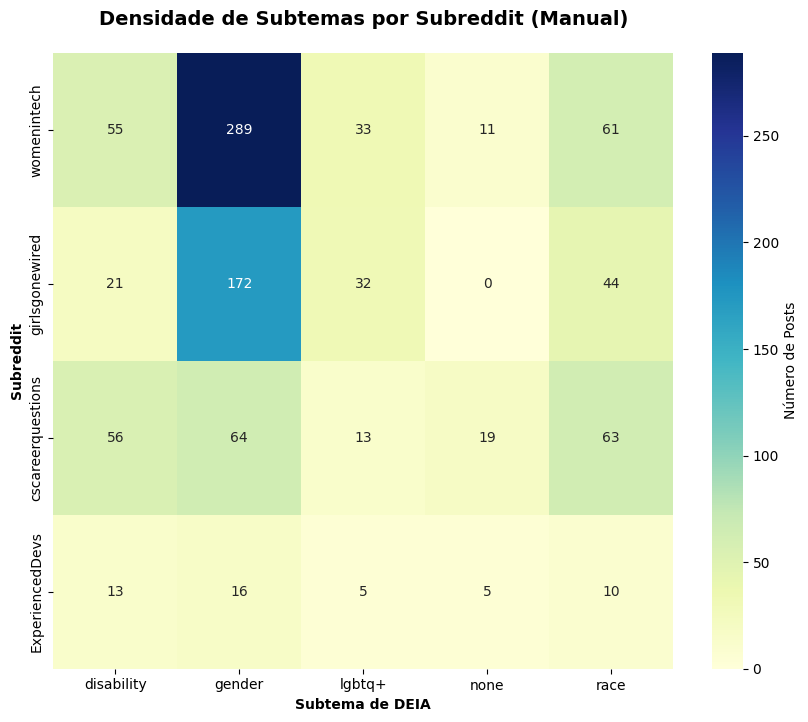

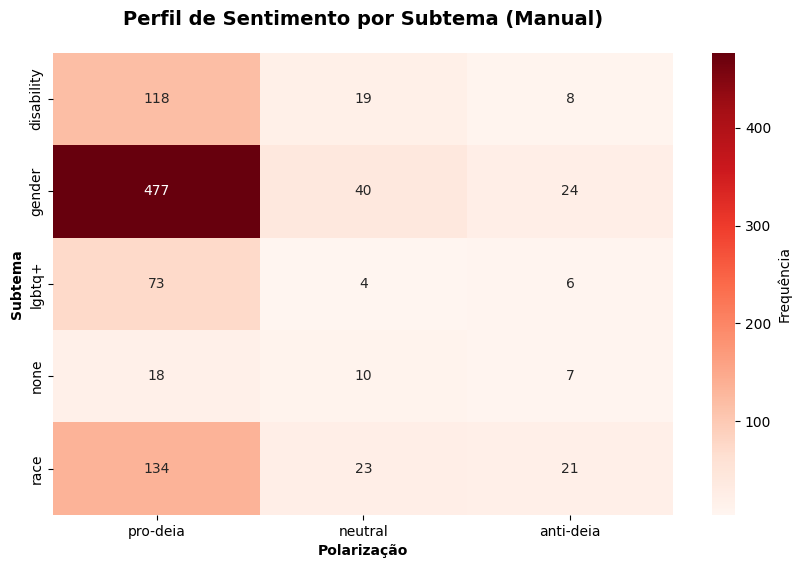

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv('PANDEIA_Manual_Labeling_Final.csv')

# 2. Filter for DEIA "yes" only
df = df[df['IS_DEIA?'].str.lower() == 'yes'].copy()

# 3. Subtheme Cleaning and Explosion
themes_validos = ['gender', 'race', 'disability', 'lgbtq+', 'none']

def clean_subthemes(val):
    if pd.isna(val): return []
    parts = [x.strip().lower() for x in str(val).split(',')]
    cleaned = []
    for p in parts:
        if 'lgbt' in p: cleaned.append('lgbtq+')
        elif p in themes_validos: cleaned.append(p)
    return list(set(cleaned))

# Adjust 'SubTheme_x' to 'Agreement_Subthemes' if using your local version
df['sub_list'] = df['Agreement_Subthemes'].apply(clean_subthemes)
df_exploded = df.explode('sub_list')
df_exploded = df_exploded[df_exploded['sub_list'].isin(themes_validos)]

# --- HEATMAP 1: Subtheme vs Subreddit ---
pivot_sub = df_exploded.groupby(['Subreddit', 'sub_list']).size().unstack(fill_value=0)
# Order subreddits by total volume for easier reading
pivot_sub = pivot_sub.loc[pivot_sub.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_sub, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Subthemes per Subreddit (Manual Labeling)', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Subreddit', fontweight='bold')
plt.xlabel('Subthemes', fontweight='bold')
plt.savefig('heatmap_temas_comunidades.png', dpi=300, bbox_inches='tight')

# --- HEATMAP 2: Subtheme vs Polarization ---
df_exploded['pol'] = df_exploded['Agreement_Polarization'].str.lower().str.strip()
pol_order = ['pro-deia', 'neutral', 'anti-deia']
pivot_pol = df_exploded.groupby(['sub_list', 'pol']).size().unstack(fill_value=0)
pivot_pol = pivot_pol.reindex(columns=pol_order)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_pol, annot=True, fmt='d', cmap='Reds')
plt.title('Sentiment Profile by Subtheme (Manual)', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Subtheme', fontweight='bold')
plt.xlabel('Polarization', fontweight='bold')
plt.savefig('heatmap_temas_polarizacao.png', dpi=300, bbox_inches='tight')

plt.show()

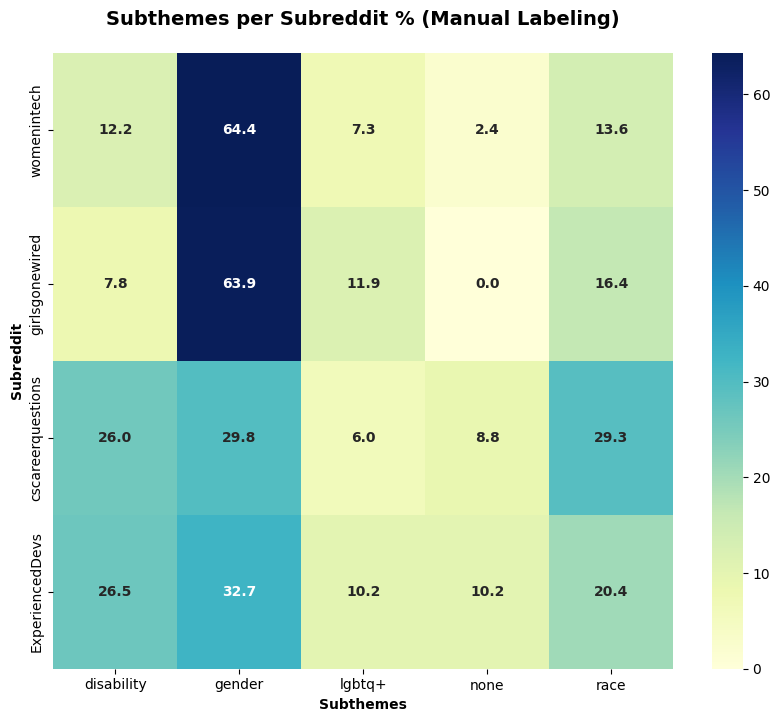

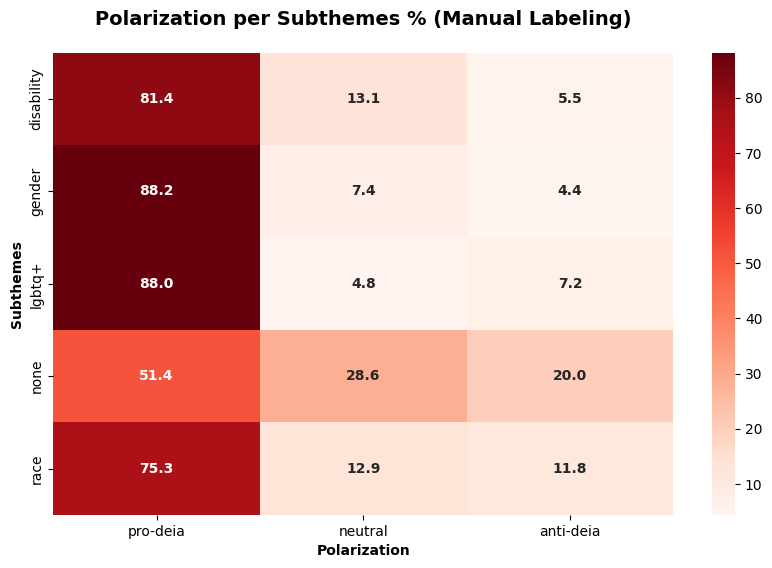

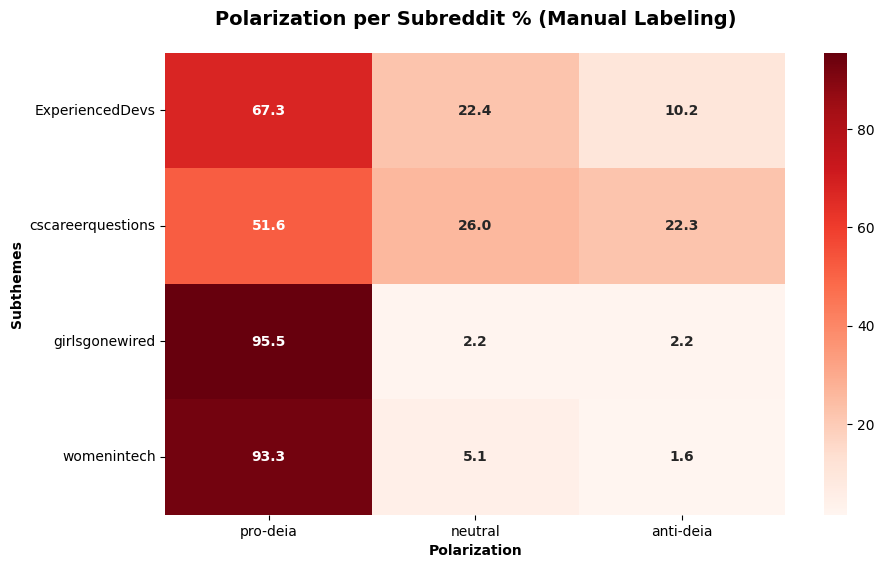

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv('PANDEIA_Manual_Labeling_Final.csv')

# 2. Filter for DEIA "yes" only
df = df[df['IS_DEIA?'].str.lower() == 'yes'].copy()

# 3. Subtheme Cleaning and Explosion
themes_validos = ['gender', 'race', 'disability', 'lgbtq+', 'none']

def clean_subthemes(val):
    if pd.isna(val): return []
    parts = [x.strip().lower() for x in str(val).split(',')]
    cleaned = []
    for p in parts:
        if 'lgbt' in p: cleaned.append('lgbtq+')
        elif p in themes_validos: cleaned.append(p)
    return list(set(cleaned))

# Adjust according to your file's columns
df['sub_list'] = df['Agreement_Subthemes'].apply(clean_subthemes)
df_exploded = df.explode('sub_list')
df_exploded = df_exploded[df_exploded['sub_list'].isin(themes_validos)]

# --- HEATMAP 1: Subtheme vs Subreddit (Percentage per Subreddit) ---
pivot_sub = df_exploded.groupby(['Subreddit', 'sub_list']).size().unstack(fill_value=0)
# Order subreddits by total volume
pivot_sub = pivot_sub.loc[pivot_sub.sum(axis=1).sort_values(ascending=False).index]

# Transform to percentage (each row sums to 100%)
pivot_sub_pct = pivot_sub.div(pivot_sub.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 8))
# fmt='.1f' sets one decimal place, annot_kws sets bold (weight)
sns.heatmap(pivot_sub_pct, annot=True, fmt='.1f', cmap='YlGnBu',
            annot_kws={'weight': 'bold'})

plt.title('Subthemes per Subreddit % (Manual Labeling)', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Subreddit', fontweight='bold')
plt.xlabel('Subthemes', fontweight='bold')
plt.savefig('heatmap_temas_comunidades_pct.png', dpi=300, bbox_inches='tight')

# --- HEATMAP 2: Subtheme vs Polarization (Percentage per Subtheme) ---
# Using Position_x as an example of manual polarization
df_exploded['pol'] = df_exploded['Agreement_Polarization'].str.lower().str.strip()
pol_order = ['pro-deia', 'neutral', 'anti-deia']
pivot_pol = df_exploded.groupby(['sub_list', 'pol']).size().unstack(fill_value=0)
pivot_pol = pivot_pol.reindex(columns=pol_order).fillna(0)

# Transform to percentage (each row/subtheme sums to 100%)
pivot_pol_pct = pivot_pol.div(pivot_pol.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_pol_pct, annot=True, fmt='.1f', cmap='Reds',
            annot_kws={'weight': 'bold'})

plt.title('Polarization per Subthemes % (Manual Labeling)', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Subthemes', fontweight='bold')
plt.xlabel('Polarization', fontweight='bold')
plt.savefig('heatmap_temas_polarizacao_pct.png', dpi=300, bbox_inches='tight')

plt.show()
# --- HEATMAP 3: Subreddit vs Polarization (Percentage per Subtheme) ---
# Using Position_x as an example of manual polarization
df_exploded['pol'] = df_exploded['Agreement_Polarization'].str.lower().str.strip()
pol_order = ['pro-deia', 'neutral', 'anti-deia']
pivot_pol = df_exploded.groupby(['Subreddit', 'pol']).size().unstack(fill_value=0)
pivot_pol = pivot_pol.reindex(columns=pol_order).fillna(0)

# Transform to percentage (each row/subtheme sums to 100%)
pivot_pol_pct = pivot_pol.div(pivot_pol.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_pol_pct, annot=True, fmt='.1f', cmap='Reds',
            annot_kws={'weight': 'bold'})

plt.title('Polarization per Subreddit % (Manual Labeling)', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Subthemes', fontweight='bold')
plt.xlabel('Polarization', fontweight='bold')
plt.savefig('heatmap_temas_polarizacao_pct.png', dpi=300, bbox_inches='tight')

plt.show()

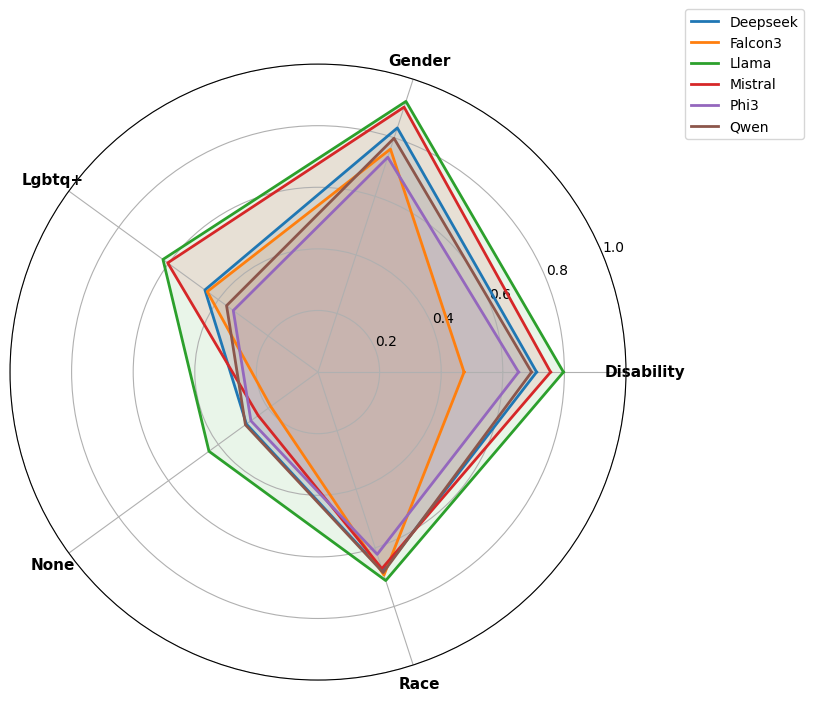

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, precision_score, recall_score
import json

# 1. File Configurations
themes = ['gender', 'race', 'disability', 'lgbtq+', 'none']
files = {
    'Manual': 'PANDEIA_Manual_Labeling_Final.csv',
    'Mistral': 'PANDEIA_RESULTS_Mistral.csv',
    'Qwen': 'PANDEIA_RESULTS_Qwen.csv',
    'Falcon3': 'PANDEIA_RESULTS_Falcon3.csv',
    'Phi3': 'PANDEIA_RESULTS_Phi3.csv',
    'Llama': 'PANDEIA_RESULTS_Llama.csv',
    'Deepseek': 'PANDEIA_RESULTS_Deepseek.csv'
}

# --- Processing Functions ---
def clean_sub(val):
    if pd.isna(val): return []
    parts = [x.strip().lower() for x in str(val).split(',')]
    return [p for p in parts if p in themes or 'lgbt' in p]

def parse_llm(val):
    try:
        data = json.loads(str(val).replace('```json', '').replace('```', ''))
        if isinstance(data.get('subtheme'), dict):
            return [k for k,v in data['subtheme'].items() if v == 1]
        return [str(x).lower() for x in data.get('subtheme', [])]
    except: return []

# 2. Load Gold Standard (Manual)
df_man = pd.read_csv(files['Manual'])
df_man = df_man[df_man['IS_DEIA?'].str.lower() == 'yes'].copy()
ids_validos = df_man['ID'].unique()

# Create ground truth matrix
y_true_all = {t: df_man['Agreement_Subthemes'].apply(lambda x: 1 if t in clean_sub(x) else 0) for t in themes}

# 3. Calculate Metrics for the 6 Models
performance_data = []

for model_name, path in files.items():
    if model_name == 'Manual': continue

    df_llm = pd.read_csv(path)
    df_llm = df_llm[df_llm['ID'].isin(ids_validos)].set_index('ID').reindex(df_man['ID'])
    df_llm['themes_pred'] = df_llm['subthemes_fewshot'].apply(parse_llm)

    for t in themes:
        y_true = y_true_all[t]
        y_pred = df_llm['themes_pred'].apply(lambda x: 1 if t in x or (t=='lgbtq+' and 'lgbt' in str(x)) else 0)

        f1 = f1_score(y_true, y_pred, zero_division=0)
        performance_data.append({'Model': model_name, 'Theme': t.capitalize(), 'F1-Score': f1})

df_metrics = pd.DataFrame(performance_data)


# --- VISUALIZATION 2: RADAR CHART ---
def plot_radar(df_pivot, title):
    categories = df_pivot.columns
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for model in df_pivot.index:
        values = df_pivot.loc[model].values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=model)
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.savefig('radar_performance_llms_Fewshot.png', dpi=300, bbox_inches='tight')

pivot_f1 = df_metrics.pivot(index='Model', columns='Theme', values='F1-Score')
plot_radar(pivot_f1, "Fewshot F1 by Model and Class")

plt.show()

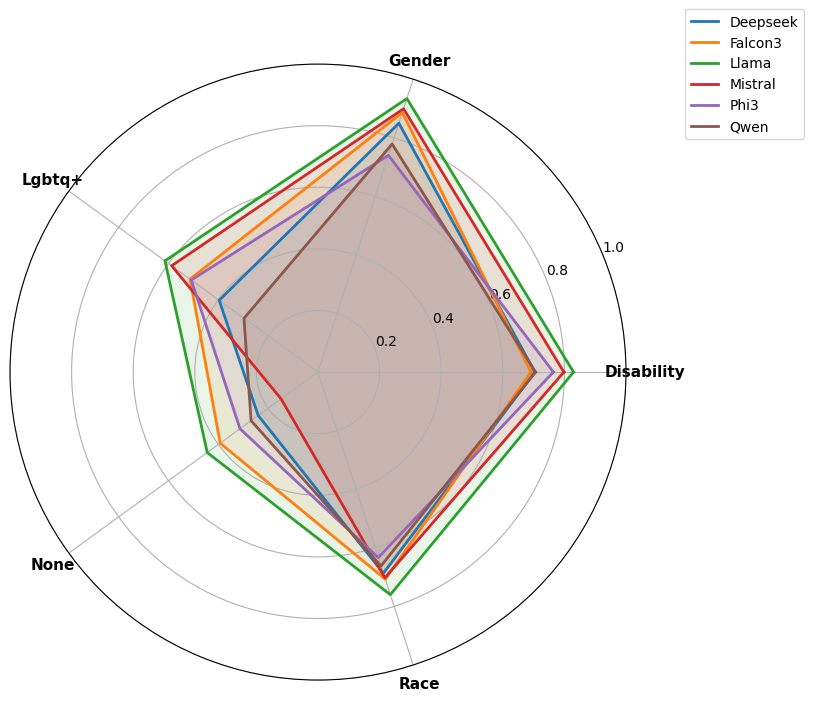

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, precision_score, recall_score
import json

# 1. File Configurations
themes = ['gender', 'race', 'disability', 'lgbtq+', 'none']
files = {
    'Manual': 'PANDEIA_Manual_Labeling_Final.csv',
    'Mistral': 'PANDEIA_RESULTS_Mistral.csv',
    'Qwen': 'PANDEIA_RESULTS_Qwen.csv',
    'Falcon3': 'PANDEIA_RESULTS_Falcon3.csv',
    'Phi3': 'PANDEIA_RESULTS_Phi3.csv',
    'Llama': 'PANDEIA_RESULTS_Llama.csv',
    'Deepseek': 'PANDEIA_RESULTS_Deepseek.csv'
}

# --- Processing Functions ---
def clean_sub(val):
    if pd.isna(val): return []
    parts = [x.strip().lower() for x in str(val).split(',')]
    return [p for p in parts if p in themes or 'lgbt' in p]

def parse_llm(val):
    try:
        data = json.loads(str(val).replace('```json', '').replace('```', ''))
        if isinstance(data.get('subtheme'), dict):
            return [k for k,v in data['subtheme'].items() if v == 1]
        return [str(x).lower() for x in data.get('subtheme', [])]
    except: return []

# 2. Load Gold Standard (Manual)
df_man = pd.read_csv(files['Manual'])
df_man = df_man[df_man['IS_DEIA?'].str.lower() == 'yes'].copy()
ids_validos = df_man['ID'].unique()

# Create ground truth matrix
y_true_all = {t: df_man['Agreement_Subthemes'].apply(lambda x: 1 if t in clean_sub(x) else 0) for t in themes}

# 3. Calculate Metrics for the 6 Models
performance_data = []

for model_name, path in files.items():
    if model_name == 'Manual': continue

    df_llm = pd.read_csv(path)
    df_llm = df_llm[df_llm['ID'].isin(ids_validos)].set_index('ID').reindex(df_man['ID'])
    df_llm['themes_pred'] = df_llm['subthemes_zeroshot'].apply(parse_llm)

    for t in themes:
        y_true = y_true_all[t]
        y_pred = df_llm['themes_pred'].apply(lambda x: 1 if t in x or (t=='lgbtq+' and 'lgbt' in str(x)) else 0)

        f1 = f1_score(y_true, y_pred, zero_division=0)
        performance_data.append({'Model': model_name, 'Theme': t.capitalize(), 'F1-Score': f1})

df_metrics = pd.DataFrame(performance_data)


# --- VISUALIZATION 2: RADAR CHART ---
def plot_radar(df_pivot, title):
    categories = df_pivot.columns
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for model in df_pivot.index:
        values = df_pivot.loc[model].values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=model)
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.savefig('radar_performance_llms_Zeroshot.png', dpi=300, bbox_inches='tight')
pivot_f1 = df_metrics.pivot(index='Model', columns='Theme', values='F1-Score')
plot_radar(pivot_f1, "Zeroshot F1 by Model and Class")

plt.show()

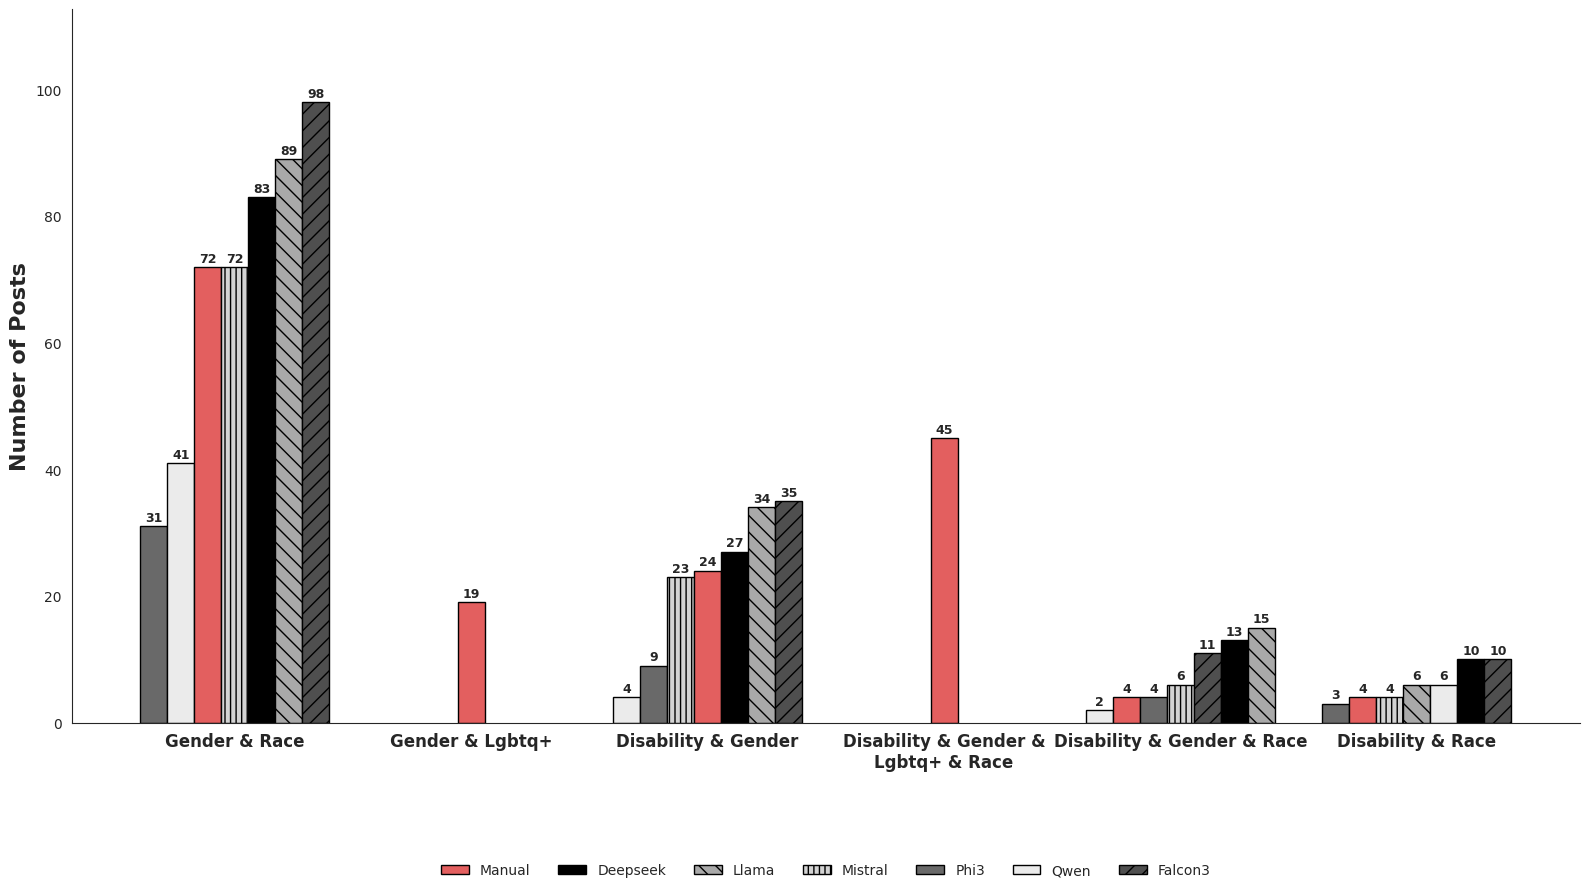

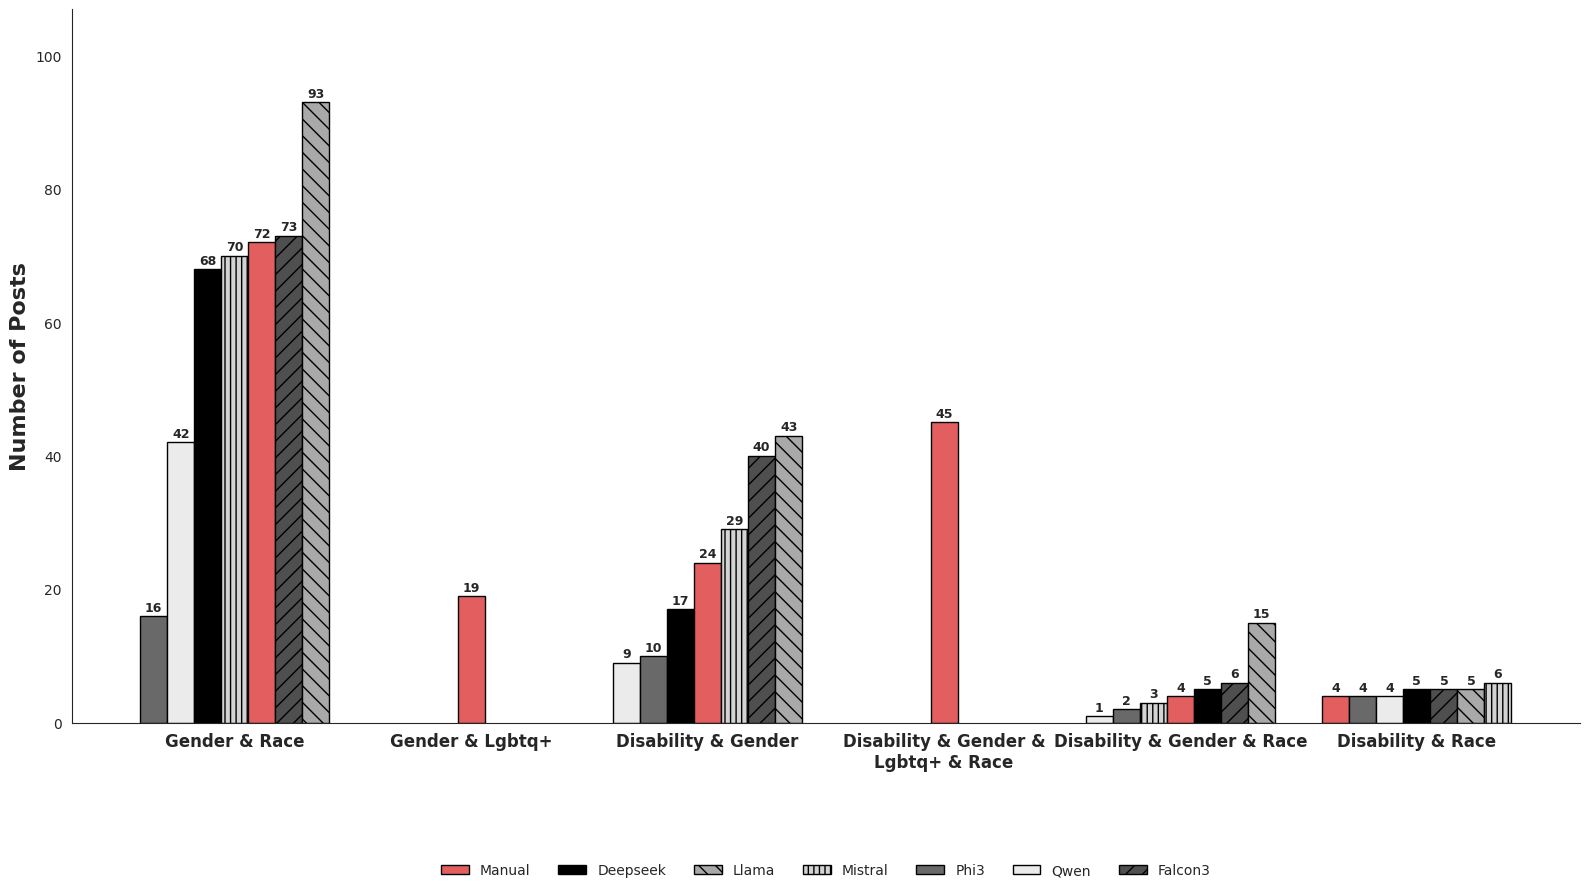

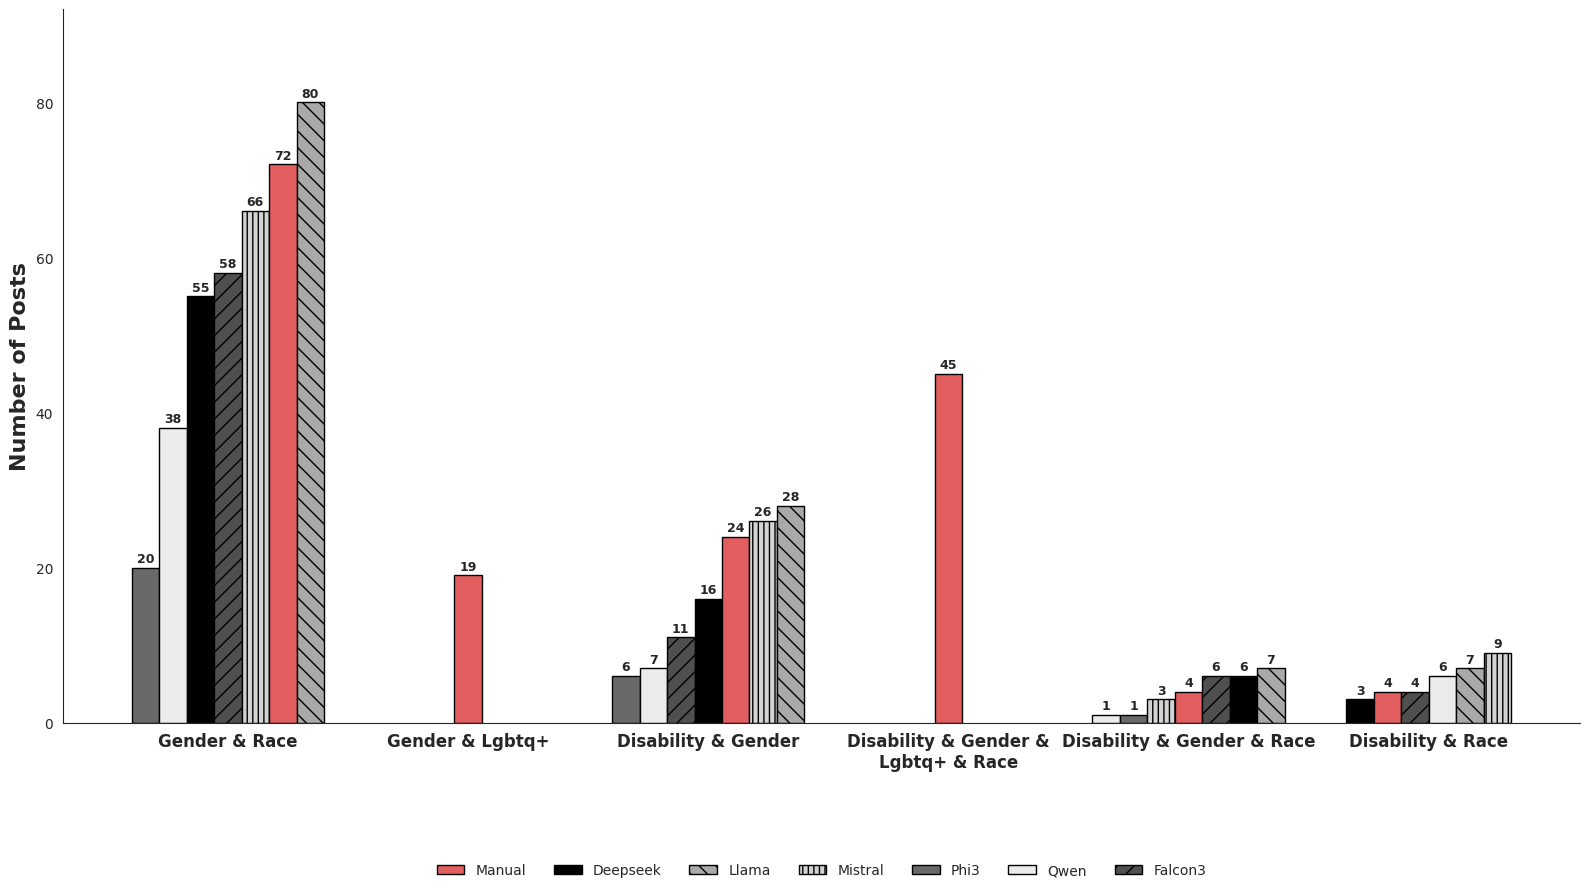

In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from matplotlib.patches import Patch

# --- 1. Configurations ---
models_files = {
    'Manual': 'PANDEIA_Manual_Labeling_Final.csv',
    'Mistral': 'PANDEIA_RESULTS_Mistral.csv',
    'Qwen': 'PANDEIA_RESULTS_Qwen.csv',
    'Falcon3': 'PANDEIA_RESULTS_Falcon3.csv',
    'Phi3': 'PANDEIA_RESULTS_Phi3.csv',
    'Llama': 'PANDEIA_RESULTS_Llama.csv',
    'Deepseek': 'PANDEIA_RESULTS_Deepseek.csv'
}
manual_file = 'PANDEIA_Manual_Labeling_Final.csv'
strategies = ['zeroshot', 'oneshot', 'fewshot']
themes_list = ['gender', 'race', 'disability', 'lgbtq+', 'none']

# CHANGE 1: Name with line break to avoid overflow
target_intersections = [
    'Gender & Race',
    'Gender & Lgbtq+',
    'Disability & Gender',
    'Disability & Gender \n &Lgbtq+ & Race',
    'Disability & Gender & Race',
    'Disability & Race'
]

# --- 2. Parsing Functions ---
def parse_manual(val):
    if pd.isna(val): return []
    parts = [x.strip().lower() for x in str(val).split(',')]
    res = []
    for p in parts:
        if 'lgbt' in p: res.append('Lgbtq+')
        elif p in themes_list and p != 'none': res.append(p.capitalize())
    return tuple(sorted(list(set(res))))

def parse_llm(val):
    try:
        data = json.loads(str(val).replace('```json', '').replace('```', '').strip())
        sub_dict = data.get('subtheme', {})
        found = []
        for k, v in sub_dict.items():
            k_clean = k.lower().replace('lgbtqia+', 'lgbtq+').replace('lgbtq', 'lgbtq+').replace('plus', '+').strip()
            if v == 1 and k_clean in themes_list and k_clean != 'none':
                if 'lgbt' in k_clean: found.append('Lgbtq+')
                else: found.append(k_clean.capitalize())
        return tuple(sorted(list(set(found))))
    except: return ()

# --- 3. Data Collection ---

# Manual Processing
df_man = pd.read_csv(manual_file)
man_inters = df_man['Agreement_Subthemes'].apply(parse_manual)
man_counts_raw = Counter([" & ".join(x) for x in man_inters if len(x) > 1])

# Normalizing names to include line break if necessary
def normalize_label(label):
    if label == 'Disability & Gender & Lgbtq+ & Race':
        return 'Disability & Gender \n &Lgbtq+ & Race'
    return label

for label, count in man_counts_raw.items():
    norm_label = normalize_label(label)
    if norm_label in target_intersections and count > 0:
        for strat in strategies:
            data_list.append({'Model': 'Manual', 'Strategy': strat, 'Intersection': norm_label, 'Count': count})

# LLM Processing
for model_name, path in models_files.items():
    try:
        df = pd.read_csv(path)
        for strat in strategies:
            col = f'subthemes_{strat}'
            if col in df.columns:
                llm_inters = df[col].apply(parse_llm)
                llm_counts_raw = Counter([" & ".join(x) for x in llm_inters if len(x) > 1])
                for label, count in llm_counts_raw.items():
                    norm_label = normalize_label(label)
                    if norm_label in target_intersections and count > 0:
                        data_list.append({'Model': model_name, 'Strategy': strat, 'Intersection': norm_label, 'Count': count})
    except Exception as e: print(f"Error in {model_name}: {e}")

full_df = pd.DataFrame(data_list)

# --- 4. Custom Plotting ---
def plot_strategy(strat_name):
    subset = full_df[full_df['Strategy'] == strat_name].copy()

    color_map = {
        'Manual': '#e35f5f', 'Deepseek': 'black', 'Llama': '#a9a9a9',
        'Mistral': '#d3d3d3', 'Phi3': '#696969', 'Qwen': '#ebebeb', 'Falcon3': '#4f4f4f'
    }
    hatch_map = {
        'Manual': '', 'Deepseek': '', 'Llama': '\\',
        'Mistral': '|||', 'Phi3': '', 'Qwen': '', 'Falcon3': '//'
    }

    fig, ax = plt.subplots(figsize=(16, 9)) # Slightly increased height

    intersections = [it for it in target_intersections if it in subset['Intersection'].unique()]
    n_intersections = len(intersections)
    width = 0.8 / 7

    for i, inter in enumerate(intersections):
        # Filters and sorts in ascending order to ensure "staircase" effect
        models_in_inter = subset[subset['Intersection'] == inter].sort_values('Count')

        start_pos = i - (len(models_in_inter) * width) / 2

        for j, (_, row) in enumerate(models_in_inter.iterrows()):
            m_name = row['Model']
            m_count = row['Count']

            ax.bar(start_pos + (j * width) + width/2, m_count, width,
                   color=color_map[m_name],
                   edgecolor='black',
                   hatch=hatch_map[m_name])

            ax.text(start_pos + (j * width) + width/2, m_count + 0.3,
                    str(int(m_count)), ha='center', va='bottom',
                    fontsize=9, fontweight='bold')
    ax.set_xticks(range(n_intersections))
    ax.set_xticklabels(intersections, fontsize=12, fontweight='bold', ha='center')
    ax.set_ylabel("Number of Posts", fontsize=16, fontweight='bold')

    # Manual legend
    legend_elements = [Patch(facecolor=color_map[m], edgecolor='black',
                             hatch=hatch_map[m], label=m) for m in color_map.keys()]

    ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.18),
              ncol=7, frameon=False, fontsize=10)

    plt.ylim(0, subset['Count'].max() * 1.15)
    sns.despine() # Clears top and right borders

    plt.tight_layout()
    plt.savefig(f'grafico_final_{strat_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

# --- 5. Execution ---
for strat in strategies:
    plot_strategy(strat)

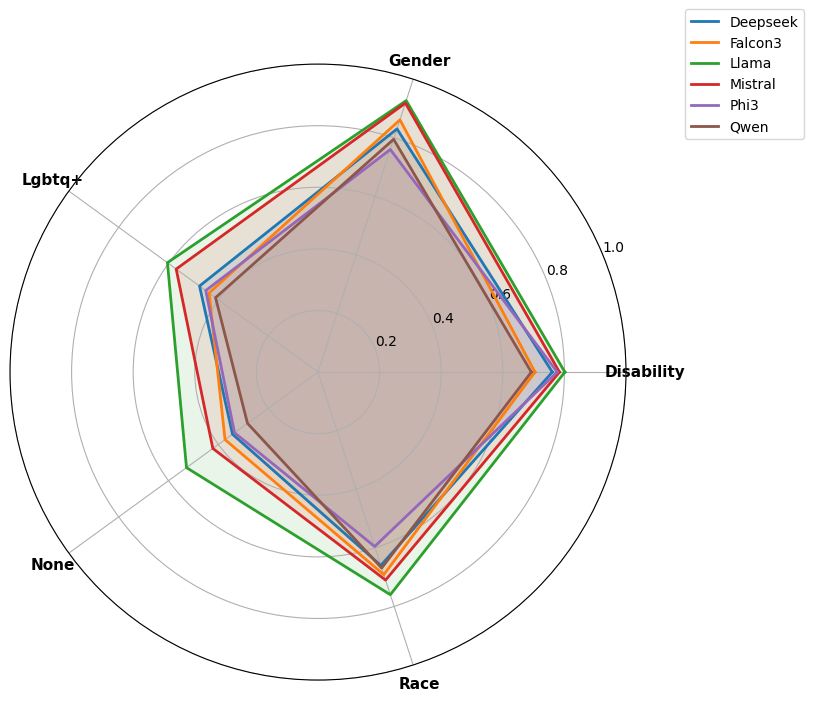

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, precision_score, recall_score
import json

# 1. File Configurations
themes = ['gender', 'race', 'disability', 'lgbtq+', 'none']
files = {
    'Manual': 'PANDEIA_Manual_Labeling_Final.csv',
    'Mistral': 'PANDEIA_RESULTS_Mistral.csv',
    'Qwen': 'PANDEIA_RESULTS_Qwen.csv',
    'Falcon3': 'PANDEIA_RESULTS_Falcon3.csv',
    'Phi3': 'PANDEIA_RESULTS_Phi3.csv',
    'Llama': 'PANDEIA_RESULTS_Llama.csv',
    'Deepseek': 'PANDEIA_RESULTS_Deepseek.csv'
}

# --- Processing Functions ---
def clean_sub(val):
    if pd.isna(val): return []
    parts = [x.strip().lower() for x in str(val).split(',')]
    return [p for p in parts if p in themes or 'lgbt' in p]

def parse_llm(val):
    try:
        data = json.loads(str(val).replace('```json', '').replace('```', ''))
        if isinstance(data.get('subtheme'), dict):
            return [k for k,v in data['subtheme'].items() if v == 1]
        return [str(x).lower() for x in data.get('subtheme', [])]
    except: return []

# 2. Load Gold Standard (Manual)
df_man = pd.read_csv(files['Manual'])
df_man = df_man[df_man['IS_DEIA?'].str.lower() == 'yes'].copy()
ids_validos = df_man['ID'].unique()

# Create ground truth matrix
y_true_all = {t: df_man['Agreement_Subthemes'].apply(lambda x: 1 if t in clean_sub(x) else 0) for t in themes}

# 3. Calculate Metrics for the 6 Models
performance_data = []

for model_name, path in files.items():
    if model_name == 'Manual': continue

    df_llm = pd.read_csv(path)
    df_llm = df_llm[df_llm['ID'].isin(ids_validos)].set_index('ID').reindex(df_man['ID'])
    df_llm['themes_pred'] = df_llm['subthemes_oneshot'].apply(parse_llm)

    for t in themes:
        y_true = y_true_all[t]
        y_pred = df_llm['themes_pred'].apply(lambda x: 1 if t in x or (t=='lgbtq+' and 'lgbt' in str(x)) else 0)

        f1 = f1_score(y_true, y_pred, zero_division=0)
        performance_data.append({'Model': model_name, 'Theme': t.capitalize(), 'F1-Score': f1})

df_metrics = pd.DataFrame(performance_data)


# --- VISUALIZATION 2: RADAR CHART ---
def plot_radar(df_pivot, title):
    categories = df_pivot.columns
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for model in df_pivot.index:
        values = df_pivot.loc[model].values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=model)
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.savefig('radar_performance_llms_oneshot.png', dpi=300, bbox_inches='tight')

pivot_f1 = df_metrics.pivot(index='Model', columns='Theme', values='F1-Score')
plot_radar(pivot_f1, "Oneshot F1 by Model and Class")

plt.show()